# California Housing Analysis / Анализ жилья в Калифорнии

**Author / Автор:** Ilya Lisitsyn  
**Contribution / Вклад:** I prepared the analysis, code, charts, web page and API.

## Abstract / Аннотация
This project is based on the California housing dataset. I compare median house value with income, location and several district characteristics. I clean the data, calculate descriptive statistics, build charts, add several new columns and check two hypotheses.

В проекте я анализирую данные о районах Калифорнии. Основная идея - посмотреть, как стоимость жилья связана с доходом, расположением и характеристиками района. В работе есть очистка данных, статистика, графики, новые признаки и проверка двух гипотез.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from analysis_utils import (
    ANALYSIS_COLUMNS,
    NUMERIC_COLUMNS,
    add_features,
    clean_data,
    descriptive_statistics,
    grouped_overview,
    load_data,
    missing_summary,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## Dataset Description / Описание датасета
The dataset contains district-level housing information from California. Each row describes one district: coordinates, housing age, room and bedroom counts, population, households, median income, median house value and ocean proximity.

В строках датасета описаны районы Калифорнии: координаты, возраст жилья, количество комнат и спален, население, домохозяйства, медианный доход, медианная стоимость жилья и близость к океану.


In [2]:
raw_df = load_data(include_new_records=False)
raw_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print(f'Rows: {raw_df.shape[0]}')
print(f'Columns: {raw_df.shape[1]}')
display(raw_df.dtypes.rename('dtype').to_frame())
display(raw_df['ocean_proximity'].value_counts().rename('count').to_frame())

Rows: 20640
Columns: 10


,dtype
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,str


,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


## Data Quality and Cleanup / Качество данных и очистка
I first checked missing values and data types. The dataset is mostly complete: the only column with missing values is `total_bedrooms`. I removed these rows before calculating statistics and building charts.

Сначала я проверил пропуски и типы данных. Данные почти полные: пропуски есть только в `total_bedrooms`. Эти строки были удалены перед анализом.


In [4]:
quality = missing_summary(raw_df)
display(quality[quality['missing_values'] > 0])

clean_df = clean_data(raw_df)
df = add_features(clean_df)

print(f'Rows before cleanup: {len(raw_df)}')
print(f'Rows after cleanup: {len(clean_df)}')
print(f'Removed rows: {len(raw_df) - len(clean_df)}')
print('All other columns have 0 missing values.')
display(missing_summary(clean_df)[lambda x: x['missing_values'] > 0])


,missing_values,missing_percent
total_bedrooms,207,1.002907


Rows before cleanup: 20640
Rows after cleanup: 20433
Removed rows: 207
All other columns have 0 missing values.


,missing_values,missing_percent


## Descriptive Statistics / Описательная статистика
The next table shows mean, median and standard deviation for seven numerical columns. These values give a quick first view of the scale and spread of the data.

В таблице ниже показаны среднее, медиана и стандартное отклонение для семи числовых колонок. Это помогает быстро понять масштаб и разброс значений.


In [5]:
descriptive_statistics(df)

,mean,median,std
housing_median_age,28.63,29.00,12.59
total_rooms,2636.50,2127.00,2185.27
total_bedrooms,537.87,435.00,421.39
population,1424.95,1166.00,1133.21
households,499.43,409.00,382.30
median_income,3.87,3.54,1.90
median_house_value,206864.41,179700.00,115435.67


## Overview Plots / Основные графики
The first plots show the general shape of the data: house value distribution, the link between income and value, differences by ocean proximity and correlations between numerical columns.

Первые графики дают общее представление о данных: распределение стоимости жилья, связь дохода и стоимости, различия по близости к океану и корреляции числовых признаков.


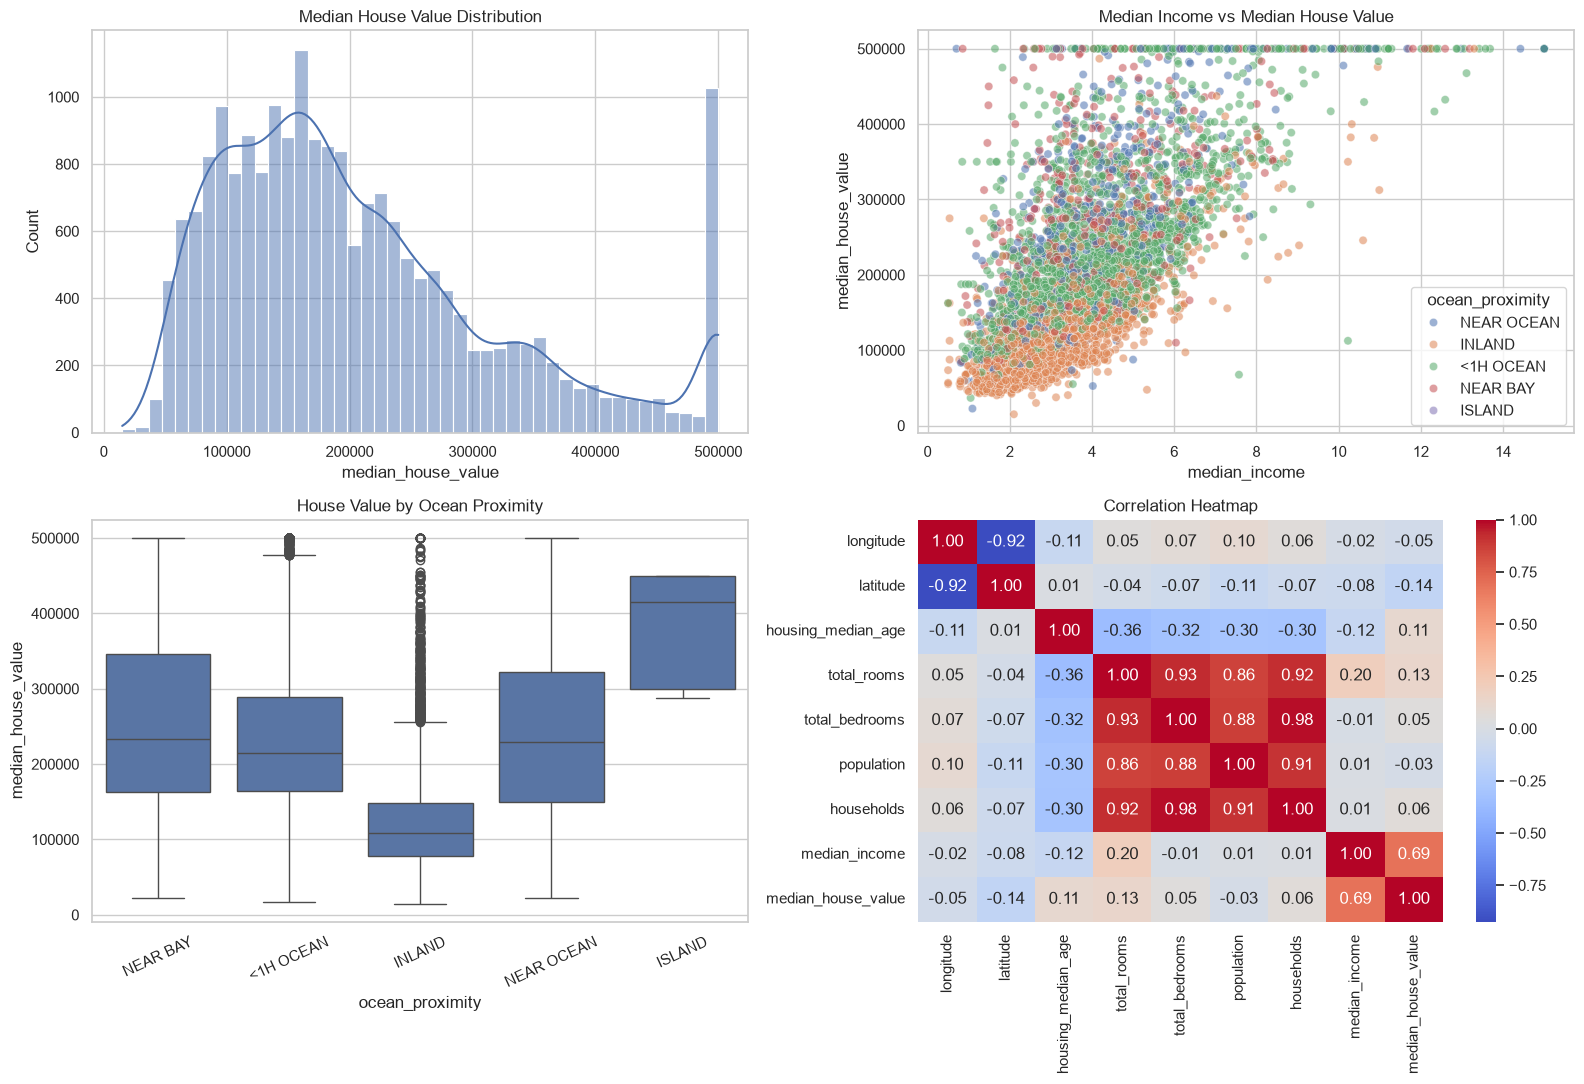

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.histplot(df['median_house_value'], bins=45, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Median House Value Distribution')

sns.scatterplot(data=df.sample(5000, random_state=42), x='median_income', y='median_house_value', hue='ocean_proximity', alpha=0.55, ax=axes[0, 1])
axes[0, 1].set_title('Median Income vs Median House Value')

sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', ax=axes[1, 0])
axes[1, 0].set_title('House Value by Ocean Proximity')
axes[1, 0].tick_params(axis='x', rotation=25)

corr = df[NUMERIC_COLUMNS].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout()

## Detailed Overview / Детальный обзор
After the general overview, I compare groups more closely. Here the main focus is location and income group, because both seem related to house value.

После общего обзора я сравниваю группы подробнее. Основной фокус здесь на расположении и группе дохода, потому что оба признака связаны со стоимостью жилья.


,ocean_proximity,income_group,districts,mean_value,median_value,mean_income,rooms_per_household
0,<1H OCEAN,low,1532,160280.88,145250.0,1.95,3.82
1,<1H OCEAN,medium,4941,216761.14,195400.0,3.67,4.85
2,<1H OCEAN,high,2561,333468.93,312000.0,6.67,6.52
3,INLAND,low,2273,83675.85,73500.0,1.89,5.23
4,INLAND,medium,3544,130201.04,120650.0,3.49,6.21
5,INLAND,high,679,235202.24,214500.0,6.17,7.33
6,ISLAND,low,1,450000.00,450000.0,2.16,5.06
7,ISLAND,medium,4,363050.00,357350.0,2.89,5.81
8,NEAR BAY,low,381,152537.29,127900.0,1.85,4.25
9,NEAR BAY,medium,1288,243085.99,218450.0,3.65,4.91


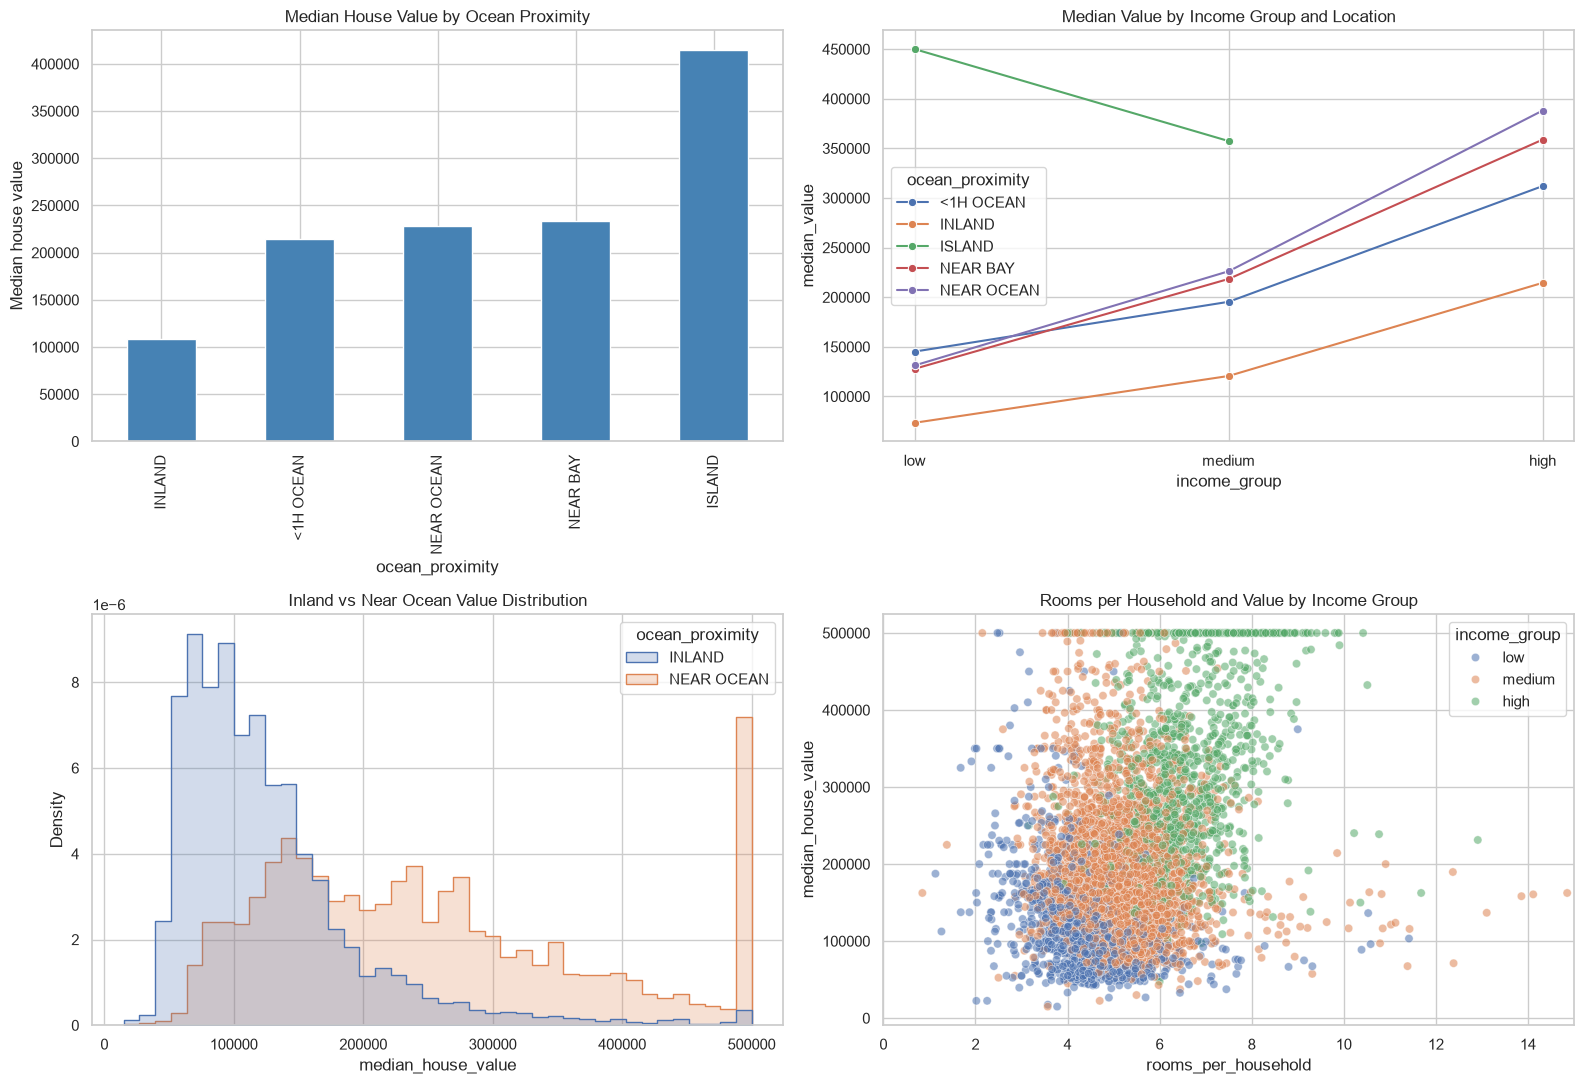

In [7]:
overview = grouped_overview(df)
display(overview)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

median_by_ocean = df.groupby('ocean_proximity')['median_house_value'].median().sort_values()
median_by_ocean.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Median House Value by Ocean Proximity')
axes[0, 0].set_ylabel('Median house value')

sns.lineplot(data=overview, x='income_group', y='median_value', hue='ocean_proximity', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Median Value by Income Group and Location')

subset = df[df['ocean_proximity'].isin(['INLAND', 'NEAR OCEAN'])]
sns.histplot(data=subset, x='median_house_value', hue='ocean_proximity', bins=40, element='step', stat='density', common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title('Inland vs Near Ocean Value Distribution')

sns.scatterplot(data=df.sample(5000, random_state=7), x='rooms_per_household', y='median_house_value', hue='income_group', alpha=0.55, ax=axes[1, 1])
axes[1, 1].set_xlim(0, 15)
axes[1, 1].set_title('Rooms per Household and Value by Income Group')

plt.tight_layout()

## Data Transformation / Преобразование данных
I added columns that are easier to compare than raw totals: `rooms_per_household`, `bedrooms_per_room`, `population_per_household` and `income_group`.

Я добавил признаки, которые удобнее сравнивать, чем исходные общие суммы: `rooms_per_household`, `bedrooms_per_room`, `population_per_household` и `income_group`.


In [8]:
df[['total_rooms', 'households', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_group']].head(10)

,total_rooms,households,rooms_per_household,bedrooms_per_room,population_per_household,income_group
0,880.0,126.0,6.984127,0.146591,2.555556,high
1,7099.0,1138.0,6.238137,0.155797,2.109842,high
2,1467.0,177.0,8.288136,0.129516,2.802260,high
3,1274.0,219.0,5.817352,0.184458,2.547945,high
4,1627.0,259.0,6.281853,0.172096,2.181467,medium
5,919.0,193.0,4.761658,0.231774,2.139896,medium
6,2535.0,514.0,4.931907,0.192899,2.128405,medium
7,3104.0,647.0,4.797527,0.221327,1.788253,medium
8,2555.0,595.0,4.294118,0.260274,2.026891,low
9,3549.0,714.0,4.970588,0.199211,2.172269,medium


## Hypothesis Check / Проверка гипотез

**H1:** Within the same ocean proximity category, districts with higher median income usually have higher median house value.  
**Гипотеза 1:** Внутри одной категории близости к океану районы с более высоким медианным доходом обычно имеют более высокую медианную стоимость жилья.

**H2:** Among high-income districts, coastal districts have higher median house values than inland districts.  
**Гипотеза 2:** Среди районов с высоким доходом прибрежные районы дороже внутренних.


,ocean_proximity,income_group,median_house_value
0,<1H OCEAN,low,145250.0
1,<1H OCEAN,medium,195400.0
2,<1H OCEAN,high,312000.0
3,INLAND,low,73500.0
4,INLAND,medium,120650.0
5,INLAND,high,214500.0
6,ISLAND,low,450000.0
7,ISLAND,medium,357350.0
8,NEAR BAY,low,127900.0
9,NEAR BAY,medium,218450.0


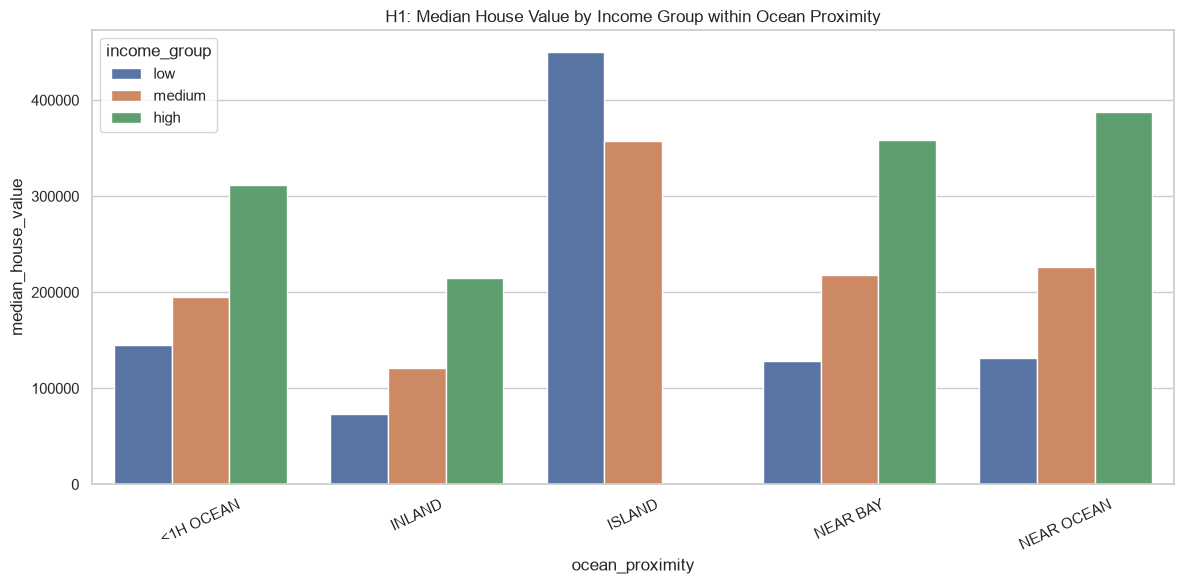

H1 result: the pattern is visible in most location groups. Higher income usually goes together with higher median house value.
Вывод по гипотезе 1: в большинстве групп стоимость жилья растет вместе с группой дохода.


In [9]:
h1 = df.groupby(['ocean_proximity', 'income_group'], observed=True)['median_house_value'].median().reset_index()
display(h1)

plt.figure(figsize=(12, 6))
sns.barplot(data=h1, x='ocean_proximity', y='median_house_value', hue='income_group')
plt.title('H1: Median House Value by Income Group within Ocean Proximity')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

print('H1 result: the pattern is visible in most location groups. Higher income usually goes together with higher median house value.')
print('Вывод по гипотезе 1: в большинстве групп стоимость жилья растет вместе с группой дохода.')


,count,mean,median,std
ocean_proximity,,,,
<1H OCEAN,2561,333468.93,312000.0,102591.64
INLAND,679,235202.24,214500.0,95648.12
NEAR BAY,601,361651.46,358800.0,103219.72
NEAR OCEAN,605,380092.69,388100.0,106221.91


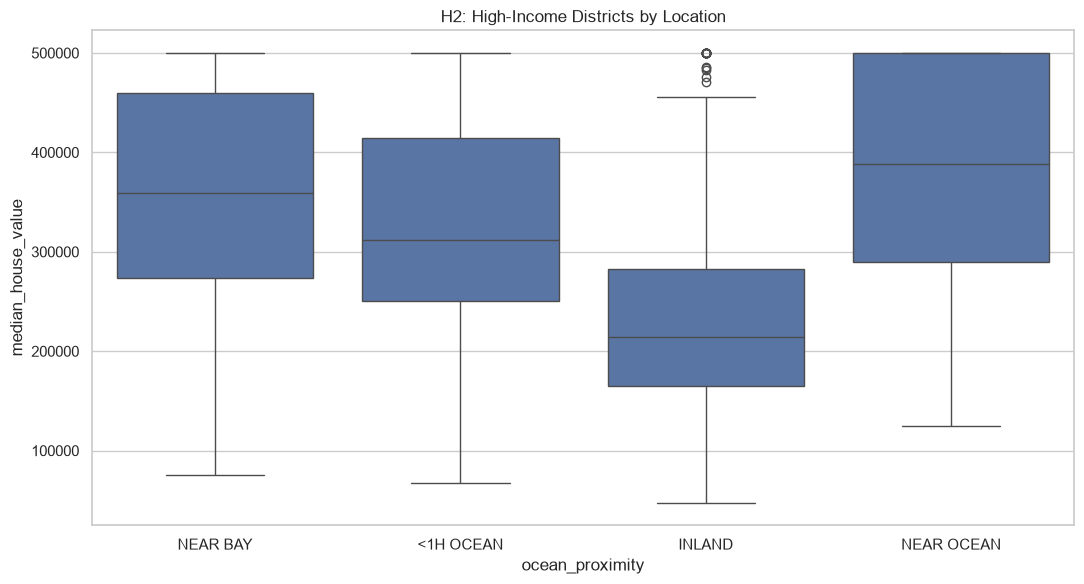

H2 result: high-income coastal groups usually have higher median values than INLAND.
Вывод по гипотезе 2: среди районов с высоким доходом прибрежные категории обычно дороже внутренних.


In [10]:
high_income = df[df['income_group'].astype(str) == 'high'].copy()
h2 = high_income[high_income['ocean_proximity'].isin(['INLAND', '<1H OCEAN', 'NEAR OCEAN', 'NEAR BAY'])]
h2_stats = h2.groupby('ocean_proximity')['median_house_value'].agg(['count', 'mean', 'median', 'std']).round(2)
display(h2_stats)

plt.figure(figsize=(11, 6))
sns.boxplot(data=h2, x='ocean_proximity', y='median_house_value')
plt.title('H2: High-Income Districts by Location')
plt.tight_layout()
plt.show()

print('H2 result: high-income coastal groups usually have higher median values than INLAND.')
print('Вывод по гипотезе 2: среди районов с высоким доходом прибрежные категории обычно дороже внутренних.')


## Discussion / Обсуждение
Median income has the clearest positive connection with median house value in this dataset. Location also matters: inland districts are usually cheaper, while districts closer to the ocean are often more expensive. The cleanup step was small because only `total_bedrooms` had missing values.

В этих данных медианный доход сильнее всего связан со стоимостью жилья. Расположение тоже заметно влияет на результат: внутренние районы обычно дешевле, а районы ближе к океану чаще дороже. Очистка была небольшой, потому что пропуски были только в колонке `total_bedrooms`.
